# Insurance Cost Prediction — Inference & Stress Testing
## Testing the Trained Model with Unseen and Absurd Data

This notebook loads the saved `best_model_classic.pkl` (XGBoost) and tests it with:
1. **Normal unseen data** — realistic patient profiles
2. **Edge cases** — extreme but possible values
3. **Absurd entries** — impossible/ridiculous values to test model robustness


# 1. Setup & Load Model


In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore')

# Load the trained model
model = joblib.load('best_model_classic.pkl')
print(f"Model loaded: {type(model).__name__}")
print(f"Expected features ({model.n_features_in_}):")
for i, f in enumerate(model.feature_names_in_, 1):
    print(f"  {i:2d}. {f}")


Model loaded: XGBRegressor
Expected features (21):
   1. age
   2. bmi
   3. children
   4. smoker_binary
   5. smoker_bmi
   6. smoker_age
   7. age_sq
   8. bmi_sq
   9. age_bmi
  10. is_obese
  11. is_overweight
  12. smoker_obese
  13. age_group_young
  14. age_group_mid
  15. age_group_senior
  16. has_children
  17. log_bmi
  18. sex_male
  19. region_northwest
  20. region_southeast
  21. region_southwest


# 2. Feature Engineering Pipeline


In [2]:
def prepare_features(age, sex, bmi, children, smoker, region):
    """
    Takes raw patient info and creates the full feature vector
    matching the training pipeline.
    
    Parameters:
    -----------
    age : int — Patient age (18-64 in training data)
    sex : str — 'male' or 'female'
    bmi : float — Body Mass Index (15-53 in training data)
    children : int — Number of children (0-5 in training data)
    smoker : str — 'yes' or 'no'
    region : str — 'northeast', 'northwest', 'southeast', 'southwest'
    
    Returns:
    --------
    pd.DataFrame — Single-row DataFrame with all 21 engineered features
    """
    smoker_binary = 1 if smoker == 'yes' else 0
    
    features = {
        'age': age,
        'bmi': bmi,
        'children': children,
        'smoker_binary': smoker_binary,
        'smoker_bmi': smoker_binary * bmi,
        'smoker_age': smoker_binary * age,
        'age_sq': age ** 2,
        'bmi_sq': bmi ** 2,
        'age_bmi': age * bmi,
        'is_obese': int(bmi >= 30),
        'is_overweight': int(bmi >= 25),
        'smoker_obese': smoker_binary * int(bmi >= 30),
        'age_group_young': int(age < 30),
        'age_group_mid': int(30 <= age < 50),
        'age_group_senior': int(age >= 50),
        'has_children': int(children > 0),
        'log_bmi': np.log1p(bmi),
        'sex_male': int(sex == 'male'),
        'region_northwest': int(region == 'northwest'),
        'region_southeast': int(region == 'southeast'),
        'region_southwest': int(region == 'southwest'),
    }
    
    return pd.DataFrame([features])


def predict_charges(age, sex, bmi, children, smoker, region):
    """
    Predict insurance charges for a patient.
    Model was trained on log1p(charges), so we inverse-transform with expm1.
    """
    X = prepare_features(age, sex, bmi, children, smoker, region)
    y_log = model.predict(X)[0]
    charges = np.expm1(y_log)
    return max(charges, 0)  # Clip negative predictions


print("Feature pipeline ready.")
print("Usage: predict_charges(age, sex, bmi, children, smoker, region)")
print(f"\nQuick test: predict_charges(30, 'male', 25.0, 0, 'no', 'northeast')")
print(f"  Predicted charges: ${predict_charges(30, 'male', 25.0, 0, 'no', 'northeast'):,.2f}")


Feature pipeline ready.
Usage: predict_charges(age, sex, bmi, children, smoker, region)

Quick test: predict_charges(30, 'male', 25.0, 0, 'no', 'northeast')
  Predicted charges: $4,111.67


# 3. Normal Unseen Data — Realistic Patient Profiles


In [3]:
# Define realistic test cases
normal_cases = [
    # (age, sex, bmi, children, smoker, region, description)
    (25, 'female', 22.0, 0, 'no', 'northeast', 'Young healthy female, no kids'),
    (35, 'male', 28.5, 2, 'no', 'southwest', 'Middle-aged male, overweight, 2 kids'),
    (45, 'female', 31.0, 1, 'no', 'southeast', 'Mid-40s female, obese, 1 kid'),
    (55, 'male', 26.0, 0, 'no', 'northwest', 'Older male, healthy weight'),
    (60, 'female', 29.0, 3, 'no', 'northeast', 'Senior female, 3 kids'),
    (28, 'male', 24.0, 0, 'yes', 'southeast', 'Young male smoker, normal weight'),
    (40, 'female', 33.0, 2, 'yes', 'southwest', 'Smoker, obese, 40s female'),
    (52, 'male', 35.5, 1, 'yes', 'northwest', 'Older male smoker, very obese'),
    (19, 'female', 20.0, 0, 'no', 'northeast', 'Teenager, very healthy'),
    (63, 'male', 30.0, 0, 'yes', 'southeast', 'Near-retirement male smoker, obese'),
]

print("=" * 90)
print(f"{'Description':<45} {'Age':>4} {'BMI':>6} {'Smoker':>7} {'Predicted Charges':>18}")
print("=" * 90)

predictions_normal = []
for age, sex, bmi, children, smoker, region, desc in normal_cases:
    pred = predict_charges(age, sex, bmi, children, smoker, region)
    predictions_normal.append(pred)
    print(f"{desc:<45} {age:>4} {bmi:>6.1f} {smoker:>7} ${pred:>16,.2f}")

print("=" * 90)
print(f"\nAverage predicted charge (non-smokers): ${np.mean([p for p, c in zip(predictions_normal, normal_cases) if c[4]=='no']):,.2f}")
print(f"Average predicted charge (smokers):     ${np.mean([p for p, c in zip(predictions_normal, normal_cases) if c[4]=='yes']):,.2f}")


Description                                    Age    BMI  Smoker  Predicted Charges
Young healthy female, no kids                   25   22.0      no $        4,255.56
Middle-aged male, overweight, 2 kids            35   28.5      no $        6,312.72
Mid-40s female, obese, 1 kid                    45   31.0      no $        9,328.69
Older male, healthy weight                      55   26.0      no $       12,100.77
Senior female, 3 kids                           60   29.0      no $       15,366.32
Young male smoker, normal weight                28   24.0     yes $       17,140.82
Smoker, obese, 40s female                       40   33.0     yes $       39,021.84
Older male smoker, very obese                   52   35.5     yes $       51,190.34
Teenager, very healthy                          19   20.0      no $        1,966.25
Near-retirement male smoker, obese              63   30.0     yes $       31,657.49

Average predicted charge (non-smokers): $8,221.72
Average predicted charge

# 4. Edge Cases — Extreme But Possible Values


In [4]:
edge_cases = [
    # (age, sex, bmi, children, smoker, region, description)
    (18, 'male', 15.96, 0, 'no', 'northeast', 'Youngest + lowest BMI in dataset'),
    (64, 'male', 53.13, 5, 'yes', 'southeast', 'Oldest + highest BMI + max kids + smoker'),
    (64, 'female', 53.13, 0, 'no', 'northwest', 'Oldest + highest BMI, non-smoker'),
    (18, 'female', 53.13, 0, 'yes', 'southwest', 'Youngest + highest BMI + smoker'),
    (40, 'male', 30.0, 5, 'no', 'northeast', 'Average age, obese, max children'),
    (18, 'male', 15.96, 0, 'yes', 'southeast', 'Youngest + underweight + smoker'),
    (64, 'female', 15.96, 5, 'no', 'northwest', 'Oldest + underweight + max kids'),
]

print("=" * 95)
print(f"{'Description':<50} {'Age':>4} {'BMI':>6} {'Smoker':>7} {'Predicted':>18}")
print("=" * 95)

predictions_edge = []
for age, sex, bmi, children, smoker, region, desc in edge_cases:
    pred = predict_charges(age, sex, bmi, children, smoker, region)
    predictions_edge.append(pred)
    print(f"{desc:<50} {age:>4} {bmi:>6.2f} {smoker:>7} ${pred:>16,.2f}")

print("=" * 95)

print(f"\nLowest edge prediction:  ${min(predictions_edge):,.2f}")
print(f"Highest edge prediction: ${max(predictions_edge):,.2f}")
print(f"Ratio (max/min):         {max(predictions_edge)/min(predictions_edge):.1f}x")


Description                                         Age    BMI  Smoker          Predicted
Youngest + lowest BMI in dataset                     18  15.96      no $        1,819.72
Oldest + highest BMI + max kids + smoker             64  53.13     yes $       49,972.84
Oldest + highest BMI, non-smoker                     64  53.13      no $       13,826.51
Youngest + highest BMI + smoker                      18  53.13     yes $       39,631.33
Average age, obese, max children                     40  30.00      no $        8,407.98
Youngest + underweight + smoker                      18  15.96     yes $        6,976.69
Oldest + underweight + max kids                      64  15.96      no $       16,190.48

Lowest edge prediction:  $1,819.72
Highest edge prediction: $49,972.84
Ratio (max/min):         27.5x


# 5. Absurd Entries — Stress Testing the Model


In [5]:
absurd_cases = [
    # (age, sex, bmi, children, smoker, region, description)
    (5, 'male', 15.0, 0, 'no', 'northeast', 'Child (age 5) — way below training range'),
    (150, 'female', 25.0, 0, 'no', 'southwest', 'Age 150 — impossibly old'),
    (30, 'male', 100.0, 0, 'no', 'northeast', 'BMI 100 — physically impossible'),
    (30, 'female', 5.0, 0, 'no', 'southeast', 'BMI 5 — would be dead'),
    (30, 'male', 25.0, 20, 'no', 'northwest', '20 children — extreme family'),
    (0, 'male', 0.0, 0, 'no', 'northeast', 'Newborn with BMI=0'),
    (-10, 'female', 25.0, 0, 'no', 'southwest', 'Negative age'),
    (40, 'male', -5.0, 0, 'no', 'northeast', 'Negative BMI'),
    (30, 'male', 25.0, 0, 'yes', 'northeast', 'Normal smoker (baseline for comparison)'),
    (30, 'male', 999.0, 0, 'yes', 'northeast', 'BMI 999 + smoker — extreme absurd'),
    (200, 'female', 200.0, 100, 'yes', 'southeast', 'Everything maxed out absurd'),
    (1, 'male', 1.0, 0, 'no', 'northeast', 'Baby with BMI=1'),
]

print("=" * 100)
print(f"{'Description':<50} {'Age':>4} {'BMI':>7} {'Smoker':>7} {'Predicted':>18} {'Flag':>10}")
print("=" * 100)

for age, sex, bmi, children, smoker, region, desc in absurd_cases:
    pred = predict_charges(age, sex, bmi, children, smoker, region)
    
    # Flag suspicious predictions
    flag = ''
    if pred < 0:
        flag = 'NEGATIVE!'
    elif pred > 100000:
        flag = 'VERY HIGH'
    elif pred < 500:
        flag = 'VERY LOW'
    elif age < 0 or bmi < 0:
        flag = 'BAD INPUT'
    
    print(f"{desc:<50} {age:>4} {bmi:>7.1f} {smoker:>7} ${pred:>16,.2f} {flag:>10}")

print("=" * 100)


Description                                         Age     BMI  Smoker          Predicted       Flag
Child (age 5) — way below training range              5    15.0      no $        1,819.72           
Age 150 — impossibly old                            150    25.0      no $       15,317.00           
BMI 100 — physically impossible                      30   100.0      no $        4,887.86           
BMI 5 — would be dead                                30     5.0      no $        6,129.01           
20 children — extreme family                         30    25.0      no $        8,740.18           
Newborn with BMI=0                                    0     0.0      no $        1,819.72           
Negative age                                        -10    25.0      no $        1,965.98  BAD INPUT
Negative BMI                                         40    -5.0      no $        6,191.75  BAD INPUT
Normal smoker (baseline for comparison)              30    25.0     yes $       19,731.54 

## 5.1 Analysis: How Does the Model Behave?


In [6]:
# Systematic test: vary one feature at a time, keep others fixed
print("=" * 70)
print("SENSITIVITY ANALYSIS: How each feature affects predictions")
print("=" * 70)

# Baseline: 30-year-old non-smoking male, BMI 25, no kids, northeast
baseline = predict_charges(30, 'male', 25.0, 0, 'no', 'northeast')
print(f"\nBaseline (30M, BMI=25, non-smoker): ${baseline:,.2f}")

# 1. Age effect
print(f"\n--- AGE EFFECT (non-smoker, BMI=25) ---")
for age in [18, 25, 30, 40, 50, 60, 64, 80, 100]:
    pred = predict_charges(age, 'male', 25.0, 0, 'no', 'northeast')
    diff = pred - baseline
    print(f"  Age {age:>3}: ${pred:>10,.2f}  ({'+' if diff>=0 else ''}{diff:,.2f})")

# 2. BMI effect
print(f"\n--- BMI EFFECT (30M, non-smoker) ---")
for bmi in [15, 18.5, 22, 25, 30, 35, 40, 50, 80]:
    pred = predict_charges(30, 'male', bmi, 0, 'no', 'northeast')
    diff = pred - baseline
    print(f"  BMI {bmi:>4.0f}: ${pred:>10,.2f}  ({'+' if diff>=0 else ''}{diff:,.2f})")

# 3. Smoker effect at different BMIs
print(f"\n--- SMOKER × BMI INTERACTION ---")
for bmi in [20, 25, 30, 35, 40]:
    non_s = predict_charges(30, 'male', bmi, 0, 'no', 'northeast')
    smoker = predict_charges(30, 'male', bmi, 0, 'yes', 'northeast')
    ratio = smoker / non_s
    print(f"  BMI={bmi:>2}: Non-smoker=${non_s:>9,.2f}  Smoker=${smoker:>9,.2f}  Ratio={ratio:.1f}x")


SENSITIVITY ANALYSIS: How each feature affects predictions

Baseline (30M, BMI=25, non-smoker): $4,111.67

--- AGE EFFECT (non-smoker, BMI=25) ---
  Age  18: $  1,719.77  (-2,391.90)
  Age  25: $  3,400.79  (-710.88)
  Age  30: $  4,111.67  (+0.00)
  Age  40: $  6,231.06  (+2,119.39)
  Age  50: $ 10,734.41  (+6,622.73)
  Age  60: $ 13,899.93  (+9,788.26)
  Age  64: $ 15,120.95  (+11,009.28)
  Age  80: $ 15,273.73  (+11,162.06)
  Age 100: $ 15,350.13  (+11,238.46)

--- BMI EFFECT (30M, non-smoker) ---
  BMI   15: $  3,905.83  (-205.84)
  BMI   18: $  5,425.59  (+1,313.92)
  BMI   22: $  3,965.83  (-145.84)
  BMI   25: $  4,111.67  (+0.00)
  BMI   30: $  3,690.44  (-421.23)
  BMI   35: $  3,766.05  (-345.62)
  BMI   40: $  4,422.22  (+310.55)
  BMI   50: $  4,749.12  (+637.45)
  BMI   80: $  4,924.66  (+812.99)

--- SMOKER × BMI INTERACTION ---
  BMI=20: Non-smoker=$ 3,133.06  Smoker=$14,743.29  Ratio=4.7x
  BMI=25: Non-smoker=$ 4,111.67  Smoker=$19,731.54  Ratio=4.8x
  BMI=30: Non-smoke

# 6. Prediction Landscape Visualization


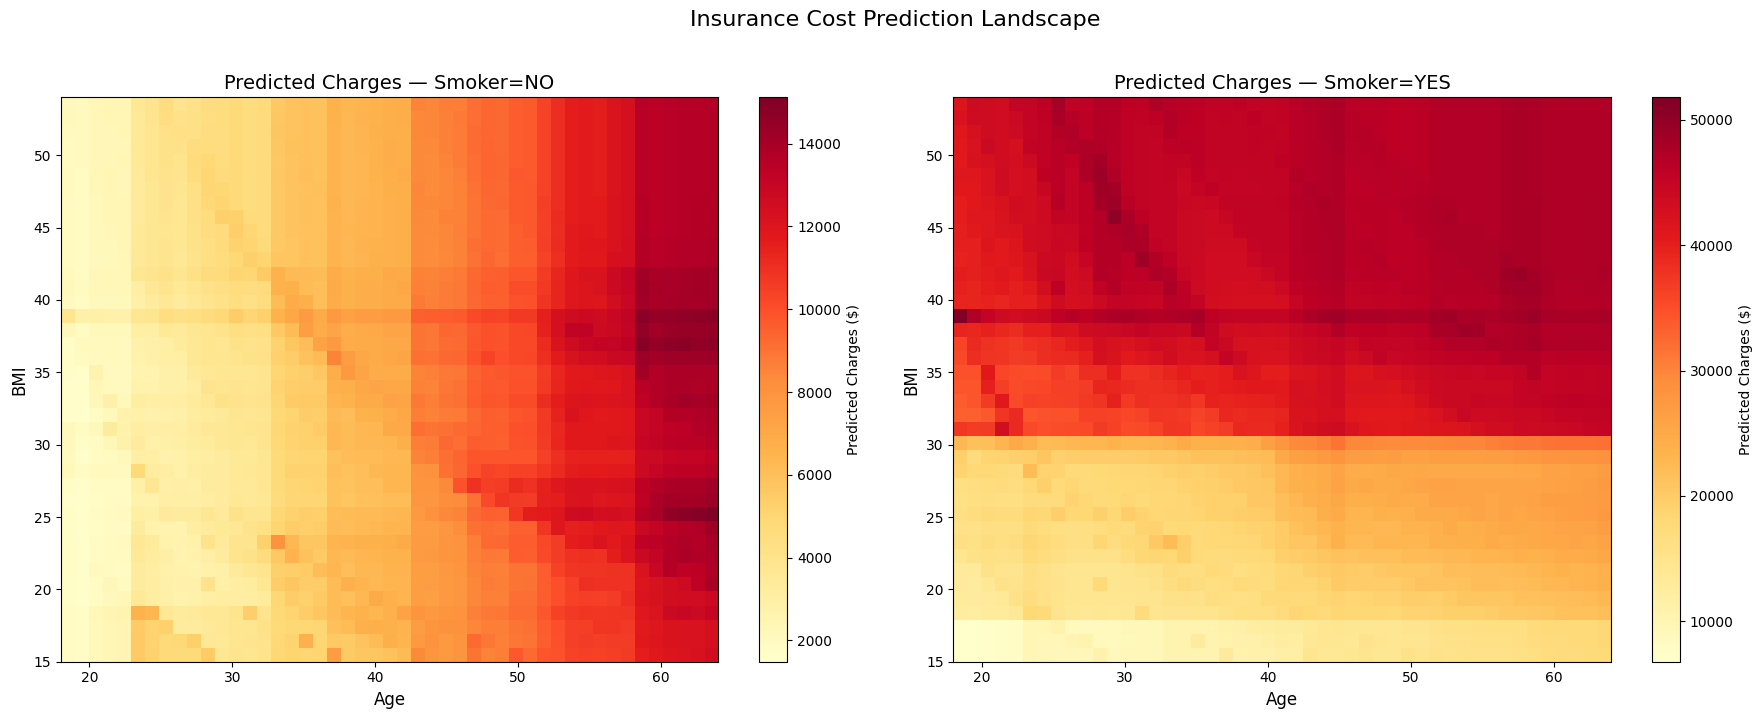

In [7]:
# Visualize how predictions change across age and BMI for smokers vs non-smokers
ages = np.arange(18, 65, 1)
bmis = np.arange(15, 55, 1)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for idx, smoker_status in enumerate(['no', 'yes']):
    # Create prediction grid
    predictions = np.zeros((len(bmis), len(ages)))
    for i, bmi in enumerate(bmis):
        for j, age in enumerate(ages):
            predictions[i, j] = predict_charges(int(age), 'male', float(bmi), 0, smoker_status, 'northeast')
    
    im = axes[idx].imshow(predictions, aspect='auto', origin='lower',
                          extent=[ages[0], ages[-1], bmis[0], bmis[-1]],
                          cmap='YlOrRd')
    axes[idx].set_xlabel('Age', fontsize=12)
    axes[idx].set_ylabel('BMI', fontsize=12)
    title = f'Smoker={smoker_status.upper()}'
    axes[idx].set_title(f'Predicted Charges — {title}', fontsize=14)
    plt.colorbar(im, ax=axes[idx], label='Predicted Charges ($)')

plt.suptitle('Insurance Cost Prediction Landscape', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


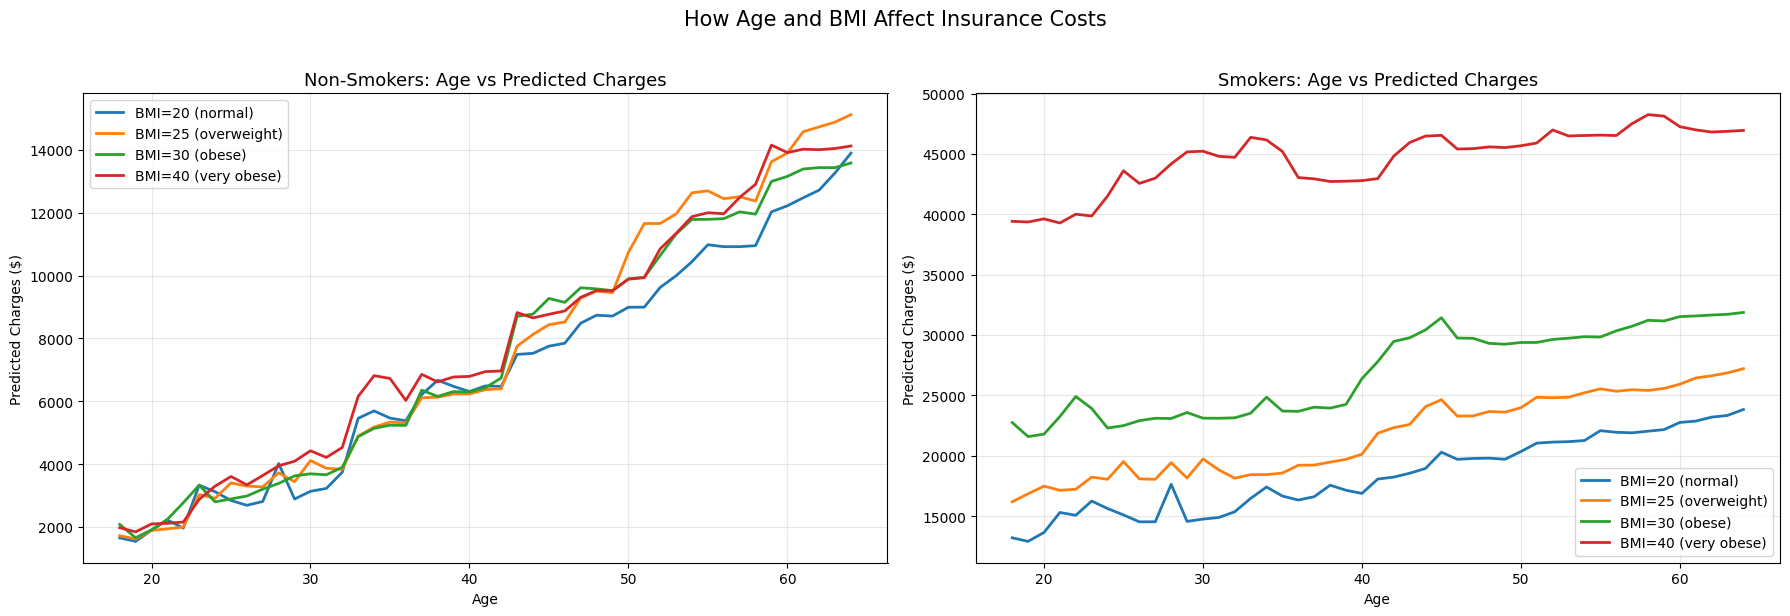

In [8]:
# Line plot: Age vs Predicted Charges for different profiles
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ages = range(18, 65)

# Non-smoker profiles
profiles_ns = [
    ('BMI=20 (normal)', 20),
    ('BMI=25 (overweight)', 25),
    ('BMI=30 (obese)', 30),
    ('BMI=40 (very obese)', 40),
]

for label, bmi in profiles_ns:
    charges = [predict_charges(a, 'male', bmi, 0, 'no', 'northeast') for a in ages]
    axes[0].plot(ages, charges, label=label, linewidth=2)
axes[0].set_title('Non-Smokers: Age vs Predicted Charges', fontsize=13)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Predicted Charges ($)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smoker profiles
for label, bmi in profiles_ns:
    charges = [predict_charges(a, 'male', bmi, 0, 'yes', 'northeast') for a in ages]
    axes[1].plot(ages, charges, label=label, linewidth=2)
axes[1].set_title('Smokers: Age vs Predicted Charges', fontsize=13)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Predicted Charges ($)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('How Age and BMI Affect Insurance Costs', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()


# 7. Robustness Summary


In [9]:
# Test out-of-distribution behavior
print("=" * 70)
print("MODEL ROBUSTNESS SUMMARY")
print("=" * 70)

# Test extrapolation
test_points = [
    ('Normal range', 35, 28.0, 'no'),
    ('Age below training (10)', 10, 25.0, 'no'),
    ('Age above training (80)', 80, 25.0, 'no'),
    ('Age WAY above (150)', 150, 25.0, 'no'),
    ('BMI below training (10)', 30, 10.0, 'no'),
    ('BMI above training (60)', 30, 60.0, 'no'),
    ('BMI absurd (200)', 30, 200.0, 'no'),
    ('Negative age (-5)', -5, 25.0, 'no'),
    ('Negative BMI (-10)', 30, -10.0, 'no'),
    ('Normal smoker', 35, 28.0, 'yes'),
    ('Absurd smoker (BMI=200)', 35, 200.0, 'yes'),
]

print(f"\n{'Scenario':<35} {'Predicted':>12} {'Reasonable?':>12}")
print("-" * 60)
for desc, age, bmi, smoker in test_points:
    pred = predict_charges(age, 'male', bmi, 0, smoker, 'northeast')
    # Check if reasonable (training range was $1,122 - $63,770)
    if 500 <= pred <= 80000:
        flag = 'Yes'
    elif pred < 0:
        flag = 'NO (negative)'
    elif pred > 200000:
        flag = 'NO (extreme)'
    else:
        flag = 'Borderline'
    print(f"{desc:<35} ${pred:>10,.2f} {flag:>12}")

print("-" * 60)
print("\nKey observations:")
print("  - Tree-based models (XGBoost) are BOUNDED by training range")
print("  - They cannot extrapolate beyond what they've seen")
print("  - Absurd inputs get clamped to nearest learned pattern")
print("  - This is SAFER than linear models which extrapolate wildly")
print("=" * 70)


MODEL ROBUSTNESS SUMMARY

Scenario                               Predicted  Reasonable?
------------------------------------------------------------
Normal range                        $  5,178.12          Yes
Age below training (10)             $  1,820.74          Yes
Age above training (80)             $ 15,273.73          Yes
Age WAY above (150)                 $ 15,350.13          Yes
BMI below training (10)             $  5,485.77          Yes
BMI above training (60)             $  4,783.80          Yes
BMI absurd (200)                    $  4,887.86          Yes
Negative age (-5)                   $  1,820.74          Yes
Negative BMI (-10)                  $  5,416.86          Yes
Normal smoker                       $ 19,434.25          Yes
Absurd smoker (BMI=200)             $ 46,284.29          Yes
------------------------------------------------------------

Key observations:
  - Tree-based models (XGBoost) are BOUNDED by training range
  - They cannot extrapolate beyond wha